In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.linear_model import LinearRegression
from sklearn.metrics import (
    mean_absolute_error,
    r2_score,
    mean_absolute_percentage_error
)


In [19]:
df = pd.read_csv('data/historico_vendas.csv',  index_col='TS', parse_dates=True)

In [20]:
df

,Sales
TS,
1964-12-31,41738
1965-12-31,46370
1966-12-31,52052
1967-12-31,60192
1968-12-31,64447
1969-12-31,68561
1970-12-31,60079
1971-12-31,67687


In [23]:
x = df.index.year.values.reshape(-1, 1)
y = df['Sales']


In [24]:
#modelo

modelo = LinearRegression().fit(x, y)

In [ ]:
anos_anteriores = x.copy()
previsoes_anteriores = modelo.predict(anos_anteriores)

anos_futuros = np.array([1972, 1973, 1974])
previsoes_futuras = modelo.predict(anos_futuros.reshape(-1, 1))

In [28]:
previsoes_futuras

array([73924.85714286, 77543.54761905, 81162.23809524])

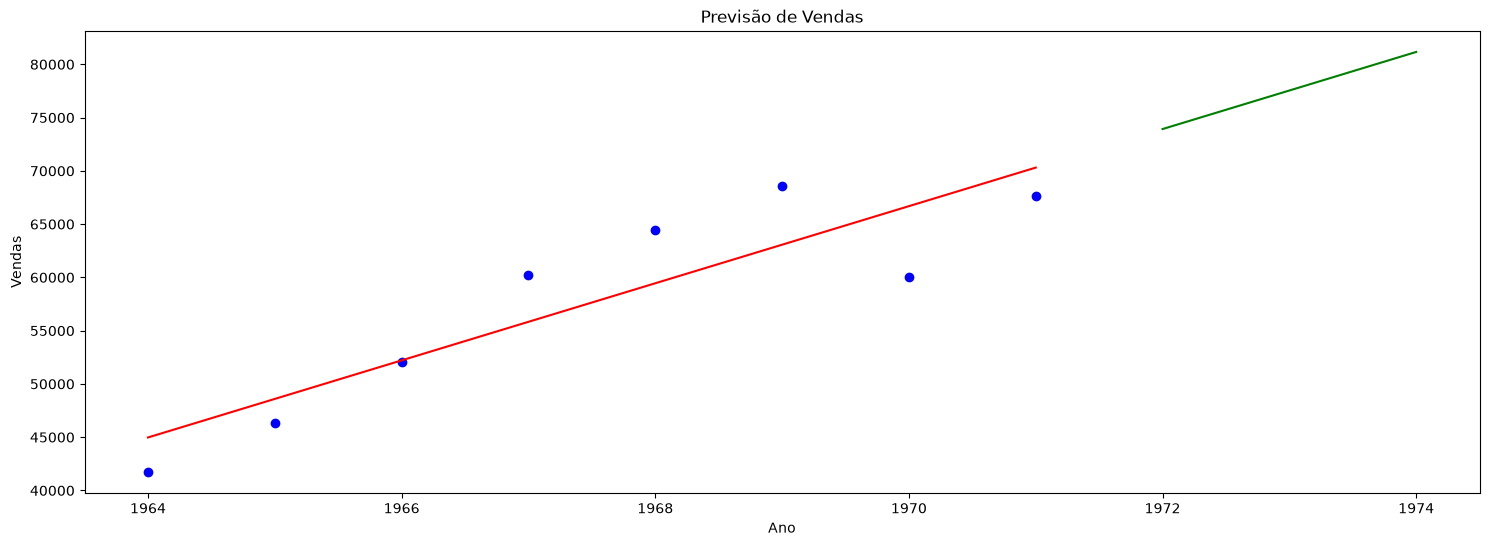

In [ ]:
plt.figure(figsize=(18, 6))

plt.scatter(x, y, color='blue', label='Dados Historicos')
plt.plot(anos_anteriores, previsoes_anteriores, color='red', label='Regressão Linear')
plt.scatter(anos_futuros, previsoes_futuras, color='green', label='Previsões Futuras')
plt.xlabel('Ano')
plt.ylabel('Vendas')
plt.title('Previsão de Vendas')
plt.legend()
plt.show()

In [ ]:
r2_regression = r2_score(y_true=y, y_pred=previsoes_anteriores)